In [ ]:
import os
import numpy as np
import tifffile
import pandas as pd
from scipy import ndimage
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.ndimage import percentile_filter

# =========================================================
# 0. INPUT
# =========================================================
image_path = "20260806_PU+4_DIV18_VLP400_jGCaMP8m_firing.tif"
mask_path = "2026080i6_PU+4_DIV18_VLP400_jGCaMP8m_firing_seg.npy"
condition_label = "VLP400 jGCaMP8m"
cell_line = "E14Tg2a"

frame_interval_s = 0.43      # seconds per frame -- CHECK against your acquisition settings

baseline_percentile = 10     # F0 = this percentile of each cell's own bleach-corrected trace
n_sd_threshold = 2           # event threshold = mean + n_sd * SD of the cell's own dF/F

n_traces_to_plot = 8         # how many example single-cell traces to show

output_dir = os.path.dirname(os.path.abspath(image_path)) or "."
base_name = os.path.splitext(os.path.basename(image_path))[0]

# =========================================================
# 1. Load movie and masks
# =========================================================
movie = tifffile.imread(image_path)
print("Movie shape (T, Y, X):", movie.shape)

if movie.ndim != 3:
    raise ValueError(f"Expected a 3D (T, Y, X) time-lapse, got shape {movie.shape}")


def load_masks(path):
    arr = np.load(path, allow_pickle=True)
    if arr.dtype == object:
        return arr.item()["masks"]
    return arr


masks = load_masks(mask_path)
print("Masks shape:", masks.shape)

if masks.shape != movie.shape[1:]:
    raise ValueError(
        f"Mask shape {masks.shape} does not match movie frame shape {movie.shape[1:]}. "
        f"Masks must be a single 2D segmentation, not a stack."
    )

labels = np.unique(masks)
labels = labels[labels != 0]
n_cells = len(labels)
n_frames = movie.shape[0]
time_s = np.arange(n_frames) * frame_interval_s
print(f"Cells: {n_cells} | Frames: {n_frames} | Duration: {time_s[-1]:.1f} s")

if n_cells == 0:
    raise ValueError("No labelled cells in the mask -- check your segmentation output.")

# =========================================================
# 2. Extract raw fluorescence traces (F) per cell
# =========================================================
raw_traces = np.zeros((n_cells, n_frames), dtype=np.float64)
for t in range(n_frames):
    raw_traces[:, t] = ndimage.mean(movie[t], labels=masks, index=labels)

Movie shape (T, Y, X): (67, 512, 512)
Masks shape: (512, 512)
Cells: 363 | Frames: 67 | Duration: 28.4 s


C:\Users\Thor\AppData\Local\Temp\3\ipykernel_60348\2088912326.py:48: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, _ = curve_fit(biexp, t, low_perc, p0=initial, maxfev=20000)



Active cells (>=1 event): 320/363 (88.2%)
Mean peak dF/F: 0.317
Mean event rate: 0.058 events/s
Saved dF/F traces to: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26b\experiments\LSM\20260806_PU+4_DIV18_VLP400_jGCaMP8m_firing_E14Tg2a_dFF_traces.csv
Saved per-cell summary to: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26b\experiments\LSM\20260806_PU+4_DIV18_VLP400_jGCaMP8m_firing_E14Tg2a_dFF_summary.csv
Saved figure to: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26b\experiments\LSM\20260806_PU+4_DIV18_VLP400_jGCaMP8m_firing_E14Tg2a_dFF_traces.svg
Saved figure to: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26b\experiments\LSM\20260806_PU+4_DIV18_VLP400_jGCaMP8m_firing_E14Tg2a_dFF_traces.png


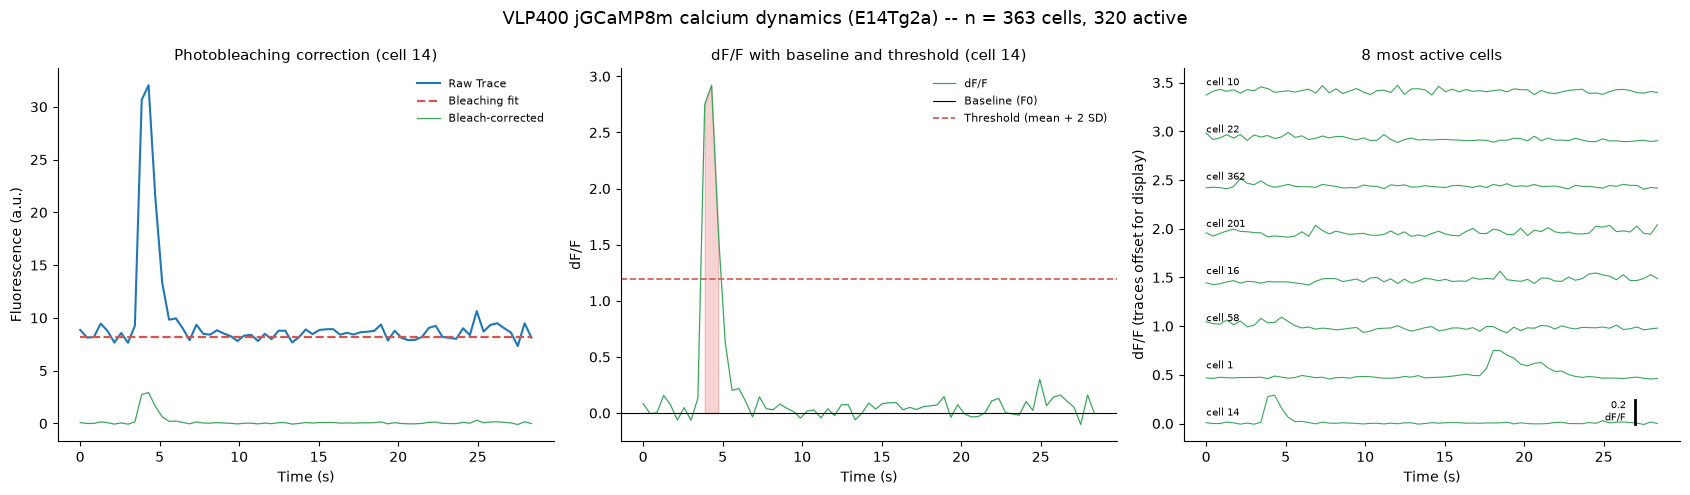

In [18]:
# =========================================================
# 3. PHOTOBLEACHING CORRECTION
# -----------------------------------------------------------------
# Fluorophores dim over the course of a recording, producing a slow
# downward drift that is NOT biological. Left uncorrected, this
# drift makes early frames look artificially "bright" and late
# frames artificially "dim", distorting dF/F.
#
# Correction: fit a bi-exponential decay to each cell's own trace
# and divide the trace by that fitted curve (normalised so the
# correction preserves the overall intensity scale). A
# bi-exponential is used because bleaching typically has a fast and
# a slow component; a single exponential often under-fits the
# early part of the decay.
#
# Fitting is done on the trace itself rather than on a separate
# background region, because bleaching rate depends on local
# fluorophore concentration and illumination, which differ per cell.
#
# NOTE: calcium transients sit ON TOP of the bleaching curve. To
# stop large transients from dragging the fit upward, the fit is
# performed on a running lower-envelope of the trace (a rolling
# minimum-percentile), which tracks the baseline rather than the
# peaks.
# =========================================================

def biexp(t, A, tau1, B, tau2, C):
    """Biexponential decay model for photobleaching baseline."""
    return A * np.exp(-t / tau1) + B * np.exp(-t / tau2) + C

size = int(2 * (1/frame_interval_s))

traces_bleach_corrected = np.zeros_like(raw_traces)
bleach_fits = np.zeros_like(raw_traces)

for i in range(n_cells):
    trace = raw_traces[i]

    initial = (
        trace[0] - trace[-1],
        10.0,
        (trace[0] - trace[-1]) * 0.5,
        50.0,
        trace[-1]
    )

    low_perc = percentile_filter(trace, 8, size=size)
    popt, _ = curve_fit(biexp, t, low_perc, p0=initial, maxfev=20000)
    baseline = biexp(t, *popt)

    bleach_fits[i] = baseline
    traces_bleach_corrected[i] = (trace - baseline) / baseline

dff = traces_bleach_corrected

# =========================================================
# 4. THRESHOLD and event detection
# -----------------------------------------------------------------
# Threshold is set per cell at mean + n_sd * SD of that cell's own
# dF/F trace. Consecutive above-threshold frames are grouped so a
# single multi-frame transient counts as one event, not several.
#
# This is a simple threshold-crossing method, NOT spike
# deconvolution -- it detects that activity occurred, not how many
# underlying action potentials produced it.
# =========================================================
summary_rows = []
thresholds = np.zeros(n_cells)

for i, lab in enumerate(labels):
    trace = dff[i]
    thr = trace.mean() + n_sd_threshold * trace.std()
    thresholds[i] = thr

    above = trace > thr
    n_events = int(np.sum(above[1:] & ~above[:-1])) + int(above[0])

    summary_rows.append({
        "label": int(lab),
        "threshold_dff": float(thr),
        "mean_dff": float(trace.mean()),
        "sd_dff": float(trace.std()),
        "max_dff": float(trace.max()),
        "n_events": n_events,
        "event_rate_per_s": n_events / (n_frames * frame_interval_s),
        "active": n_events > 0,
    })

summary_df = pd.DataFrame(summary_rows)
n_active = int(summary_df["active"].sum())
print(f"\nActive cells (>=1 event): {n_active}/{n_cells} ({100*n_active/n_cells:.1f}%)")
print(f"Mean peak dF/F: {summary_df['max_dff'].mean():.3f}")
print(f"Mean event rate: {summary_df['event_rate_per_s'].mean():.3f} events/s")

# =========================================================
# 5. Export
# =========================================================
dff_df = pd.DataFrame(dff.T, columns=[f"cell_{int(l)}" for l in labels])
dff_df.insert(0, "time_s", time_s)
dff_csv = os.path.join(output_dir, f"{base_name}_{cell_line}_dFF_traces.csv")
dff_df.to_csv(dff_csv, index=False)
print(f"Saved dF/F traces to: {dff_csv}")

summary_csv = os.path.join(output_dir, f"{base_name}_{cell_line}_dFF_summary.csv")
summary_df.to_csv(summary_csv, index=False)
print(f"Saved per-cell summary to: {summary_csv}")

# =========================================================
# 6. Figures
# =========================================================
FG = "#000000"
TRACE_COLOR = "#3AA65C"
RAW_COLOR = "#999999"
FIT_COLOR = "#D9534F"
THRESH_COLOR = "#D9534F"

fig, axes = plt.subplots(1, 3, figsize=(17, 5), facecolor="white")

# --- Panel A: bleaching correction, shown on one example cell ---
ax = axes[0]
example = int(np.argmax(summary_df["max_dff"].values))
ax.plot(time_s, raw_traces[example], label="Raw Trace")
ax.plot(time_s, bleach_fits[example], color=FIT_COLOR, linewidth=1.6,
        linestyle="--", label="Bleaching fit")
ax.plot(time_s, traces_bleach_corrected[example], color=TRACE_COLOR, linewidth=0.9,
        label="Bleach-corrected")
ax.set_xlabel("Time (s)", color=FG)
ax.set_ylabel("Fluorescence (a.u.)", color=FG)
ax.set_title(f"Photobleaching correction (cell {int(labels[example])})", color=FG, fontsize=11)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# --- Panel B: single-cell dF/F trace with baseline + threshold marked ---
ax = axes[1]
ax.plot(time_s, dff[example], color=TRACE_COLOR, linewidth=0.9, label="dF/F")
ax.axhline(0, color=FG, linewidth=0.8, linestyle="-", label="Baseline (F0)")
ax.axhline(thresholds[example], color=THRESH_COLOR, linewidth=1.2, linestyle="--",
           label=f"Threshold (mean + {n_sd_threshold} SD)")
above = dff[example] > thresholds[example]
ax.fill_between(time_s, 0, dff[example], where=above, color=THRESH_COLOR, alpha=0.25)
ax.set_xlabel("Time (s)", color=FG)
ax.set_ylabel("dF/F", color=FG)
ax.set_title(f"dF/F with baseline and threshold (cell {int(labels[example])})",
             color=FG, fontsize=11)
ax.legend(frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# --- Panel C: stacked dF/F traces of the most active cells ---
ax = axes[2]
top_idx = summary_df.nlargest(min(n_traces_to_plot, n_cells), "max_dff").index.tolist()
offset_step = np.nanpercentile(dff, 99) * 1.1
for j, idx in enumerate(top_idx):
    y = dff[idx] * 0.1 + j * offset_step
    ax.plot(time_s, y, linewidth=0.8, color=TRACE_COLOR)
    ax.text(time_s[0], j * offset_step + offset_step * 0.12,
            f"cell {int(labels[idx])}", fontsize=7, color=FG, va="bottom")
ax.set_xlabel("Time (s)", color=FG)
ax.set_ylabel("dF/F (traces offset for display)", color=FG)
ax.set_title(f"{len(top_idx)} most active cells", color=FG, fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

# scale bar for the offset traces
ax.plot([time_s[-1]*0.95, time_s[-1]*0.95], [0, offset_step*0.5],
        color=FG, linewidth=2)
ax.text(time_s[-1]*0.93, offset_step*0.25, f"{offset_step*0.5:.1f}\ndF/F",
        fontsize=7, color=FG, ha="right", va="center")

fig.suptitle(
    f"{condition_label} calcium dynamics ({cell_line}) -- "
    f"n = {n_cells} cells, {n_active} active",
    color=FG, fontsize=13
)
plt.tight_layout()

svg_path = os.path.join(output_dir, f"{base_name}_{cell_line}_dFF_traces.svg")
png_path = os.path.join(output_dir, f"{base_name}_{cell_line}_dFF_traces.png")
plt.savefig(svg_path, format="svg", facecolor="white", edgecolor="none", bbox_inches="tight")
plt.savefig(png_path, format="png", dpi=300, facecolor="white", edgecolor="none", bbox_inches="tight")
print(f"Saved figure to: {svg_path}")
print(f"Saved figure to: {png_path}")

plt.show()

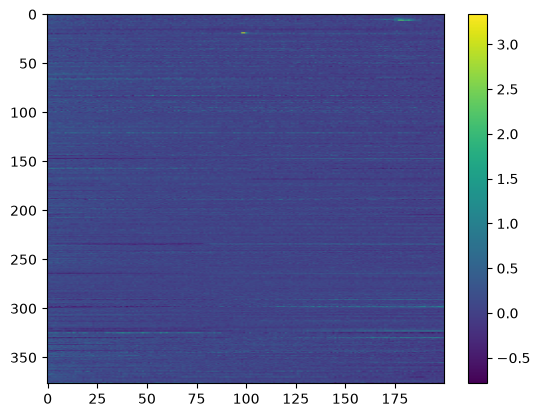

In [11]:
plt.imshow(dff, aspect="auto")
plt.colorbar()


Colour scale: -0.21 to 0.52 dF/F (data range -0.56 to 2.92)
Saved SVG to: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26b\experiments\LSM\20260806_PU+4_DIV18_VLP400_jGCaMP8m_firing_E14Tg2a_dFF_heatmap.svg
Saved PNG to: \\z-sv-dfsroot\dfsroot\project\ag-serwane\Data\Retina\Mouse\E14Tg2a\2026\E14TG2a_r26b\experiments\LSM\20260806_PU+4_DIV18_VLP400_jGCaMP8m_firing_E14Tg2a_dFF_heatmap.png


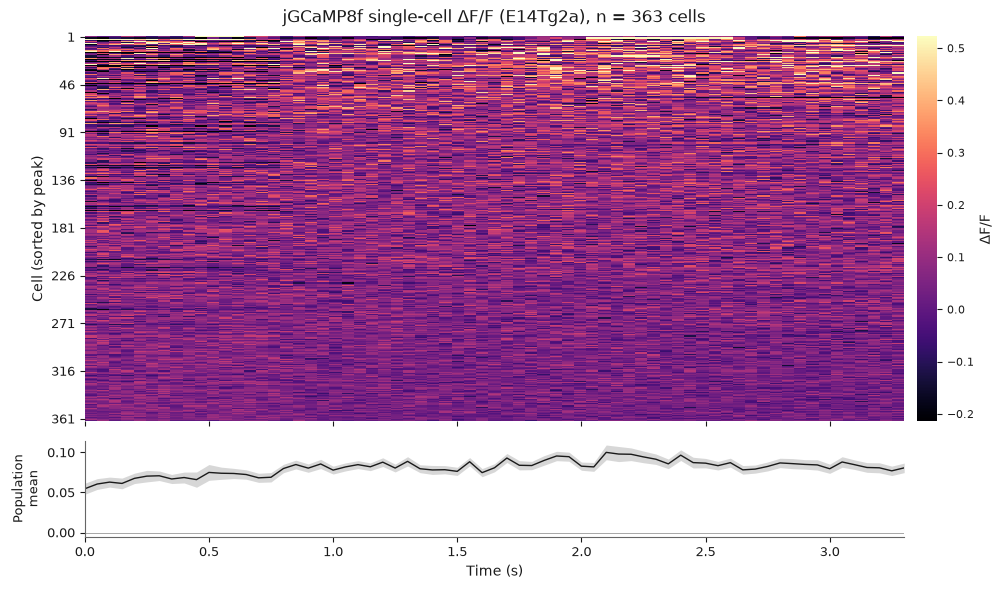

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# =========================================================
# Assumes you already have:
#   dff             -- (n_cells x n_frames) array of dF/F
#   labels          -- array of cell IDs (optional, for tick labels)
#   image_path      -- path to the source recording (used for output location/naming)
# =========================================================

# --- output location: same folder as the source image, named after it ---
try:
    output_dir = os.path.dirname(os.path.abspath(image_path)) or "."
    base_name = os.path.splitext(os.path.basename(image_path))[0]
except NameError:
    # fallback if image_path isn't defined in this session
    output_dir = "."
    base_name = "recording"
    print("NOTE: 'image_path' not found -- saving to the current folder as 'recording_*'. "
          "Define image_path to have outputs land next to your data file.")

cell_line = "E14Tg2a"            # <-- edit
condition_label = "jGCaMP8f"     # <-- edit

frame_interval_s = 0.05          # <-- edit to your acquisition rate
sort_by = "peak"                 # "peak", "mean", "onset", or "none"
show_population_trace = True
cmap = "magma"

n_cells, n_frames = dff.shape
time_s = np.arange(n_frames) * frame_interval_s

# =========================================================
# 1. Sort cells so structure is visible instead of a random jumble
# =========================================================
if sort_by == "peak":
    order = np.argsort(-dff.max(axis=1))
elif sort_by == "mean":
    order = np.argsort(-dff.mean(axis=1))
elif sort_by == "onset":
    order = np.argsort(np.argmax(dff, axis=1))
else:
    order = np.arange(n_cells)

dff_sorted = dff[order]

# =========================================================
# 2. Robust colour limits (percentiles, anchored at 0)
# =========================================================
vmax = np.percentile(dff_sorted, 99.5)
vmin = min(0, np.percentile(dff_sorted, 0.5))
print(f"Colour scale: {vmin:.2f} to {vmax:.2f} dF/F "
      f"(data range {dff_sorted.min():.2f} to {dff_sorted.max():.2f})")

# =========================================================
# 3. Figure
# =========================================================
FG = "#1a1a1a"

if show_population_trace:
    fig = plt.figure(figsize=(11, 6.5), facecolor="white")
    gs = gridspec.GridSpec(2, 2, height_ratios=[4, 1], width_ratios=[40, 1],
                           hspace=0.08, wspace=0.03)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax_pop = fig.add_subplot(gs[1, 0], sharex=ax)
else:
    fig = plt.figure(figsize=(11, 5.5), facecolor="white")
    gs = gridspec.GridSpec(1, 2, width_ratios=[40, 1], wspace=0.03)
    ax = fig.add_subplot(gs[0, 0])
    cax = fig.add_subplot(gs[0, 1])
    ax_pop = None

im = ax.imshow(
    dff_sorted,
    aspect="auto",
    cmap=cmap,
    vmin=vmin,
    vmax=vmax,
    interpolation="nearest",
    extent=[time_s[0], time_s[-1], n_cells - 0.5, -0.5],
)

ax.set_ylabel(f"Cell (sorted by {sort_by})", fontsize=10, color=FG)
ax.set_title(f"{condition_label} single-cell $\\Delta$F/F ({cell_line}), n = {n_cells} cells",
             fontsize=12, color=FG, pad=10)

if n_cells <= 20:
    ax.set_yticks(np.arange(n_cells))
    try:
        ax.set_yticklabels([int(labels[k]) for k in order], fontsize=7)
    except NameError:
        ax.set_yticklabels(np.arange(1, n_cells + 1), fontsize=7)
else:
    step = max(1, n_cells // 8)
    ax.set_yticks(np.arange(0, n_cells, step))
    ax.set_yticklabels(np.arange(1, n_cells + 1, step), fontsize=8)

ax.tick_params(labelsize=9, colors=FG)
for s in ax.spines.values():
    s.set_visible(False)

if ax_pop is not None:
    ax.tick_params(labelbottom=False)
else:
    ax.set_xlabel("Time (s)", fontsize=10, color=FG)

cbar = fig.colorbar(im, cax=cax)
cbar.set_label(r"$\Delta$F/F", fontsize=10, color=FG)
cbar.ax.tick_params(labelsize=8, colors=FG)
cbar.outline.set_visible(False)

if ax_pop is not None:
    pop_mean = dff.mean(axis=0)
    pop_sem = dff.std(axis=0) / np.sqrt(n_cells)

    ax_pop.fill_between(time_s, pop_mean - pop_sem, pop_mean + pop_sem,
                        color="#B0B0B0", alpha=0.5, linewidth=0)
    ax_pop.plot(time_s, pop_mean, color=FG, linewidth=1.0)
    ax_pop.axhline(0, color="#999999", linewidth=0.6, linestyle="-")

    ax_pop.set_xlabel("Time (s)", fontsize=10, color=FG)
    ax_pop.set_ylabel("Population\nmean", fontsize=9, color=FG)
    ax_pop.set_xlim(time_s[0], time_s[-1])
    ax_pop.tick_params(labelsize=9, colors=FG)
    ax_pop.spines[["top", "right"]].set_visible(False)
    ax_pop.spines[["left", "bottom"]].set_color("#666666")

# =========================================================
# 4. AUTOMATIC SAVING -- same folder as the source data
# -----------------------------------------------------------------
# Saved BEFORE plt.show(), because some interactive backends clear
# the figure once show() is called, which would leave you with an
# empty file if savefig ran afterwards.
# =========================================================
svg_path = os.path.join(output_dir, f"{base_name}_{cell_line}_dFF_heatmap.svg")
png_path = os.path.join(output_dir, f"{base_name}_{cell_line}_dFF_heatmap.png")

fig.savefig(svg_path, format="svg", facecolor="white", edgecolor="none", bbox_inches="tight")
fig.savefig(png_path, format="png", dpi=300, facecolor="white", edgecolor="none", bbox_inches="tight")

print(f"Saved SVG to: {svg_path}")
print(f"Saved PNG to: {png_path}")

plt.show()